In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Concatenate, GlobalAveragePooling2D, Dropout
from sklearn.model_selection import train_test_split

In [ ]:
!kaggle datasets download -d adityajn105/flickr8k -p . && \
unzip -q flickr8k.zip -d flickr8k

In [4]:
data_path = "flickr8k"
images_path = os.path.join(data_path, "Images")
captions_path = os.path.join(data_path, "captions.txt")

In [5]:
# 1. Load the captions
df = pd.read_csv(captions_path)

# For performance reasons during this project, we can sample the dataset
# df = df.sample(10000, random_state=42).reset_index(drop=True)

images = df['image'].values
captions = df['caption'].values

# 2. Create labels (1 for match, 0 for mismatch)
labels = np.ones(len(images))

# To create negative examples (mismatching image-text), we shuffle half of the captions
num_negatives = len(images) // 2
neg_indices = np.random.choice(len(images), num_negatives, replace=False)

# Shift the captions for the negative indices so they don't match exactly
shifted_captions = np.roll(captions[neg_indices], 1)
captions[neg_indices] = shifted_captions
labels[neg_indices] = 0

# Convert image names to full paths
image_paths = [os.path.join(images_path, img) for img in images]

# Split into train and validation sets
X_img_train, X_img_val, X_txt_train, X_txt_val, y_train, y_val = train_test_split(
    image_paths, captions, labels, test_size=0.2, random_state=42
)

print(f"Train samples: {len(X_img_train)}")
print(f"Validation samples: {len(X_img_val)}")

Train samples: 32364
Validation samples: 8091


In [6]:
# 3. Text Processing with Embeddings (Tokenizer and Padding)
vocab_size = 5000
max_length = 30 # Maximum words in a caption to consider

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_txt_train)

def process_texts(texts):
    # Convert words into sequences of integers
    sequences = tokenizer.texts_to_sequences(texts)
    # Pad sequences so they all have the same length
    padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    return padded

X_txt_train_pad = process_texts(X_txt_train)
X_txt_val_pad = process_texts(X_txt_val)

In [7]:
# 4. Image Processing and tf.data Setup
IMG_SIZE = (224, 224)
BATCH_SIZE = 64

def load_and_preprocess_image(image_path, caption, label):
    # Read the image file
    img = tf.io.read_file(image_path)
    # Decode to RGB
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize to dimensions expected by ResNet50
    img = tf.image.resize(img, IMG_SIZE)
    # Preprocess image as expected by ResNet50
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return (img, caption), label

# Create tf.data.Dataset for efficiency
train_dataset = tf.data.Dataset.from_tensor_slices((X_img_train, X_txt_train_pad, y_train))
# Use num_parallel_calls for faster image loading
train_dataset = train_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_img_val, X_txt_val_pad, y_val))
val_dataset = val_dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

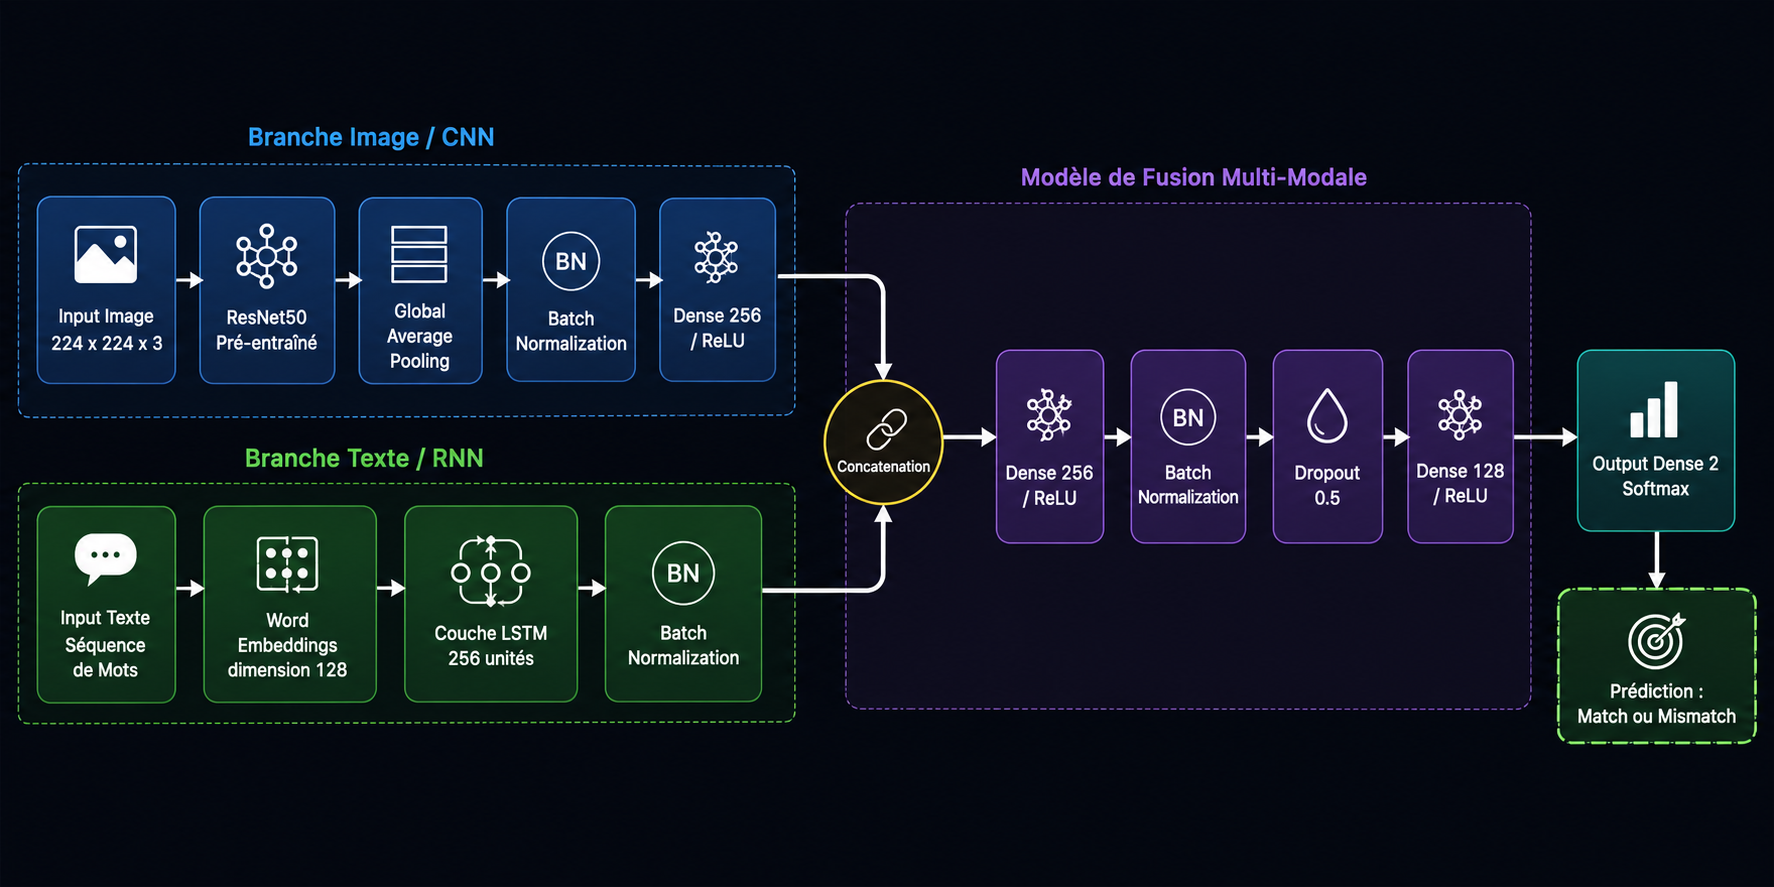

In [ ]:
from tensorflow.keras.layers import BatchNormalization

# 5. Multi-Modal Model Architecture (CNN + RNN Fusion)

# --- Image Branch (CNN) ---
image_input = Input(shape=(224, 224, 3), name='image_input')
# Use a pre-trained ResNet50
base_cnn = ResNet50(weights='imagenet', include_top=False)
base_cnn.trainable = False # Freeze convolutional base for tuning

x_img = base_cnn(image_input)
x_img = GlobalAveragePooling2D()(x_img)
x_img = BatchNormalization()(x_img) # <-- NORMALISATION
x_img = Dense(256, activation='relu')(x_img)

# --- Text Branch (RNN) ---
text_input = Input(shape=(max_length,), name='text_input')
# Word Embeddings with mask_zero=True to ignore padding
x_txt = Embedding(input_dim=vocab_size, output_dim=128, mask_zero=True)(text_input) # <-- MASK ZERO
# Recurrent Neural Network (LSTM or GRU)
x_txt = LSTM(256, return_sequences=False)(x_txt)
x_txt = BatchNormalization()(x_txt) # <-- NORMALISATION

# --- Multi-Modal Fusion ---
# Concatenate Visual and Textual features
concat = Concatenate()([x_img, x_txt])

# Fully Connected Layers for Fusion Interactions
x = Dense(256, activation='relu')(concat)
x = BatchNormalization()(x) # <-- NORMALISATION
x = Dropout(0.5)(x) # Regularization techniques
x = Dense(128, activation='relu')(x)

# Last Softmax layer assigning probability (2 classes: Match vs No Match)
output = Dense(2, activation='softmax', name='output')(x)

model = Model(inputs=[image_input, text_input], outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ image_input[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 30, 128)   │    640,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    394,240 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    131,328 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │        258 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,310,978 (96.55 MB)

 Trainable params: 1,723,266 (6.57 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# 6. Model Compile and Train
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Un taux d'apprentissage plus faible aide car la fusion image-texte est difficile au début
optimizer = Adam(learning_rate=1e-4)

# On compile le modèle dans tous les cas
model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# On utilise les POIDS (.weights.h5) au lieu du modèle entier pour éviter le bug de désérialisation Keras
if os.path.exists("multimodal_model.weights.h5"):
    print("Chargement des poids sauvegardés...")
    model.load_weights("multimodal_model.weights.h5")
else:
    print("Entraînement du modèle...")
    # Configuration de l'Early Stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',         # Surveiller la perte de validation
        patience=2,                 # S'arrêter après 2 époques sans amélioration
        restore_best_weights=True,  # Restaurer les meilleurs poids du modèle
        verbose=1
    )

    # L'Early Stopping coupera l'entraînement dès que nécessaire
    epochs = 15

    history = model.fit(
        train_dataset, 
        validation_data=val_dataset, 
        epochs=epochs,
        callbacks=[early_stopping]
    )

    
    # 7. Evaluate and Plot History
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss (Cross-Entropy)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

Chargement des poids sauvegardés...


/opt/anaconda3/envs/quant/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


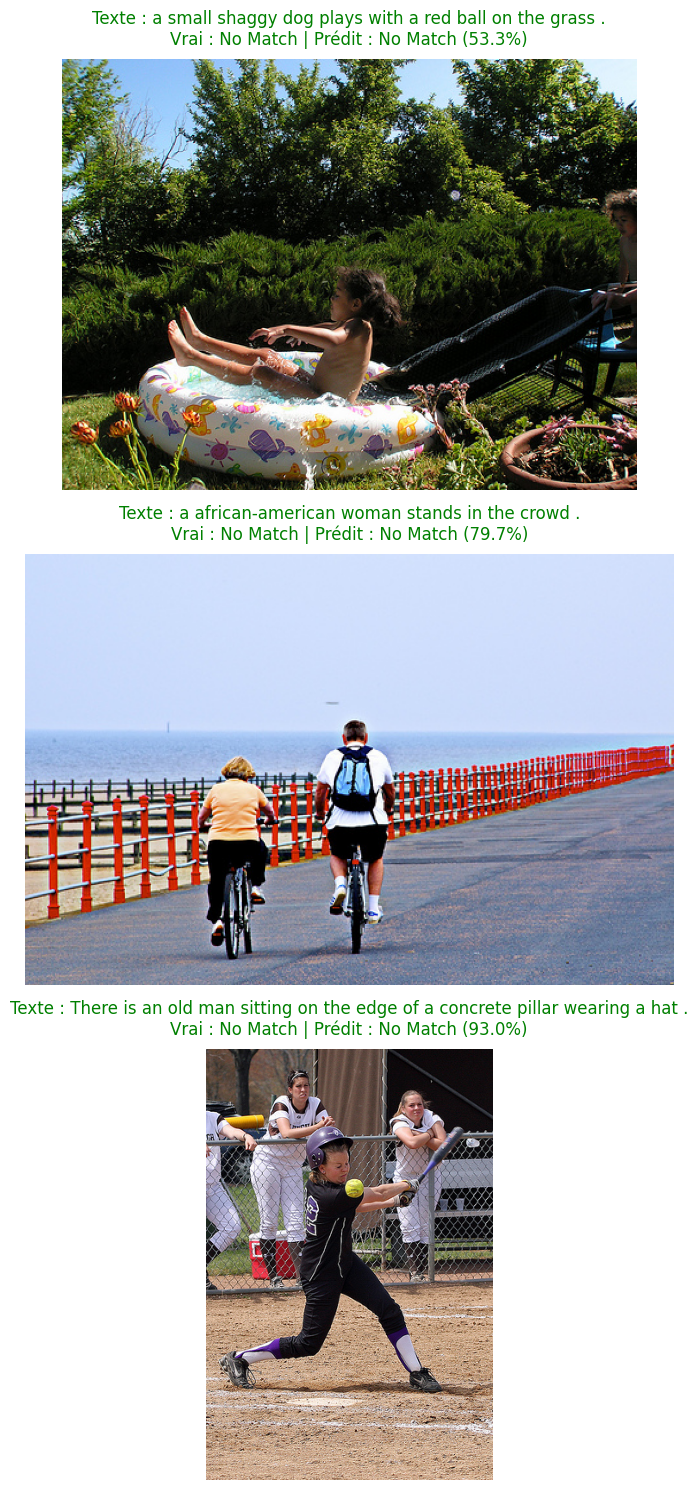

In [14]:
# 8. Inference and Visualization
import random

def visualize_predictions(num_samples=3):
    plt.figure(figsize=(10, 5 * num_samples))
    
    # Prendre des exemples aléatoires dans le set de validation
    indices = np.random.choice(len(X_img_val), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        img_path = X_img_val[idx]
        original_caption = X_txt_val[idx]
        true_label = int(y_val[idx])
        padded_text = X_txt_val_pad[idx]
        
        # --- Préparation des entrées ---
        # 1. Image (format TensorFlow / ResNet)
        img_tensor = tf.io.read_file(img_path)
        img_tensor = tf.image.decode_jpeg(img_tensor, channels=3)
        img_tensor = tf.image.resize(img_tensor, IMG_SIZE)
        img_tensor = tf.keras.applications.resnet50.preprocess_input(img_tensor)
        img_batch = tf.expand_dims(img_tensor, 0) # Ajout de la dimension batch
        
        # 2. Texte
        txt_batch = np.expand_dims(padded_text, 0) # Ajout de la dimension batch
        
        # --- Prédiction ---
        # verbose=0 enlève les logs Keras par défaut de la console
        prediction = model.predict([img_batch, txt_batch], verbose=0)[0] 
        predicted_class = np.argmax(prediction)
        confidence = prediction[predicted_class] * 100
        
        # Libellés
        class_names = ["No Match", "Match"]
        true_class_text = class_names[true_label]
        pred_class_text = class_names[predicted_class]
        
        # --- Affichage ---
        plt.subplot(num_samples, 1, i + 1)
        
        # On lit l'image normalement pour l'afficher avec les bonnes couleurs
        display_img = plt.imread(img_path)
        plt.imshow(display_img)
        plt.axis('off')
        
        # Vert si correct, rouge si le modèle s'est trompé
        color = "green" if predicted_class == true_label else "red"
        
        plt.title(f"Texte : {original_caption}\n"
                  f"Vrai : {true_class_text} | Prédit : {pred_class_text} ({confidence:.1f}%)",
                  color=color, fontsize=12, pad=10)
        
    plt.tight_layout()
    plt.show()

# Tester le modèle sur 3 exemples aléatoires du jeu de validation
visualize_predictions(3)

In [ ]:
# 9. Save the Model
import os

# Sauvegarder uniquement les POIDS du modèle au lieu de sa structure.
# Cela évite le bug de "quantization_config" lié à la couche Embedding dans les nouvelles versions de Keras
model_save_path = "multimodal_model.weights.h5"
model.save_weights(model_save_path)

print(f"Poids du modèle sauvegardés avec succès sous : {model_save_path}")

# Note: L'architecture étant déjà définie dans la Cellule 5,
# recharger les poids (model.load_weights) suffit amplement et est beaucoup plus stable.